Transfer Learning eg


In [3]:
#Install the kaggle library

!pip install kaggle

In [4]:
#configure the path for the kaggle file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


importing the data set from kaggle : https://www.kaggle.com/competitions/dogs-vs-cats

In [5]:
#kaggle api
!kaggle competitions download -c dogs-vs-cats

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [6]:
!ls

drive  sample_data


In [7]:
#extracting the compressed file data set
from zipfile import ZipFile

dataset = '/content/drive/MyDrive/Data Science/Deep Learning/11 Dog vs Cat Classification using Transfer Learning/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset is extracted")

The dataset is extracted


In [8]:
#extracting the compressed file data set
from zipfile import ZipFile

dataset = '/content/drive/MyDrive/Data Science/Deep Learning/11 Dog vs Cat Classification using Transfer Learning/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset is extracted")

The dataset is extracted


In [9]:
import os
#counting the number of files in trained folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


In [10]:
# os.listdir(path)      # list files
# os.walk(path)         # traverse folders
# os.path.join(a, b)    # safe path joining
# os.makedirs(path)     # create folders
# os.path.exists(path)  # check existence


printing the name of the images

In [11]:
file_names = os.listdir('/content/train')
print(file_names)

['cat.4808.jpg', 'dog.11702.jpg', 'dog.1662.jpg', 'cat.4595.jpg', 'dog.10223.jpg', 'cat.1089.jpg', 'cat.5543.jpg', 'cat.9958.jpg', 'dog.4388.jpg', 'dog.64.jpg', 'dog.74.jpg', 'cat.5693.jpg', 'dog.9158.jpg', 'dog.688.jpg', 'dog.580.jpg', 'cat.4872.jpg', 'cat.12277.jpg', 'cat.12093.jpg', 'dog.5898.jpg', 'cat.4540.jpg', 'cat.10912.jpg', 'cat.10361.jpg', 'cat.4704.jpg', 'cat.3989.jpg', 'dog.7786.jpg', 'cat.1420.jpg', 'dog.2972.jpg', 'dog.483.jpg', 'cat.3549.jpg', 'cat.9722.jpg', 'dog.9680.jpg', 'cat.9160.jpg', 'cat.2578.jpg', 'cat.2978.jpg', 'cat.2186.jpg', 'dog.6699.jpg', 'cat.9032.jpg', 'dog.11648.jpg', 'cat.10631.jpg', 'cat.10448.jpg', 'cat.785.jpg', 'cat.3721.jpg', 'dog.10946.jpg', 'dog.7457.jpg', 'cat.6234.jpg', 'cat.11408.jpg', 'cat.9992.jpg', 'dog.6692.jpg', 'cat.925.jpg', 'cat.2857.jpg', 'cat.7900.jpg', 'cat.1701.jpg', 'cat.2003.jpg', 'dog.8292.jpg', 'dog.2806.jpg', 'cat.10289.jpg', 'cat.1338.jpg', 'dog.2767.jpg', 'cat.515.jpg', 'dog.2828.jpg', 'dog.269.jpg', 'dog.5925.jpg', 'cat.9

Importing the Dependencies

In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

Displaying the images of dogs and cats

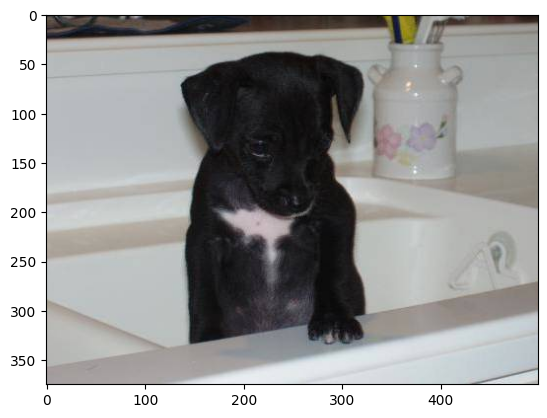

In [13]:
#display dog image
img = mpimg.imread('/content/train/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

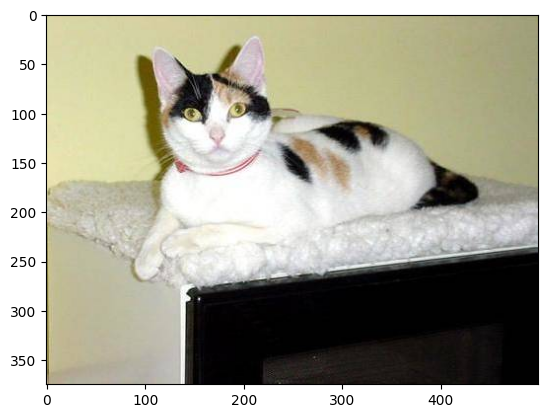

In [14]:
#display dog image
img = mpimg.imread('/content/train/cat.4808.jpg')
imgplt = plt.imshow(img)
plt.show()

Get the total number of imgs

In [18]:
files_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count +=1

  else:
    cat_count +=1

print("Number of dog images = ", dog_count)
print("Number of cat images = ", cat_count)

Number of dog images =  12500
Number of cat images =  12500


Resize the images

In [21]:
#creating a directory for resized images
os.mkdir('/content/image resized')

In [22]:
original_folder = '/content/train/'
resized_folder = '/content/image resized/'


files = os.listdir(original_folder)

cat_files = [f for f in files if f.startswith('cat')][:500]
dog_files = [f for f in files if f.startswith('dog')][:500]

for filename in cat_files + dog_files:
    img_path = os.path.join(original_folder, filename)

    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    img.save(os.path.join(resized_folder, filename))


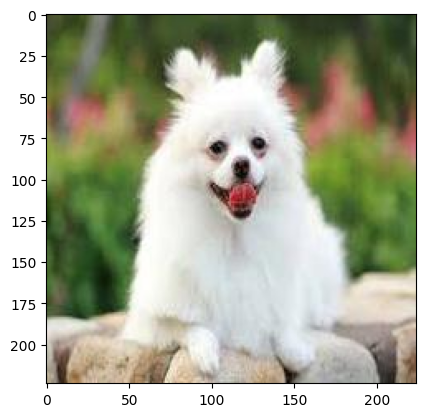

In [23]:
#resized dog image
img = mpimg.imread('/content/image resized/dog.11702.jpg')
imgplt = plt.imshow(img)
plt.show()

In [24]:
print('Dogs:', len(dog_files))

Dogs: 500


In [25]:
print('Cats:', len(cat_files))

Cats: 500


In [26]:
print(dog_files)

['dog.11702.jpg', 'dog.1662.jpg', 'dog.10223.jpg', 'dog.4388.jpg', 'dog.64.jpg', 'dog.74.jpg', 'dog.9158.jpg', 'dog.688.jpg', 'dog.580.jpg', 'dog.5898.jpg', 'dog.7786.jpg', 'dog.2972.jpg', 'dog.483.jpg', 'dog.9680.jpg', 'dog.6699.jpg', 'dog.11648.jpg', 'dog.10946.jpg', 'dog.7457.jpg', 'dog.6692.jpg', 'dog.8292.jpg', 'dog.2806.jpg', 'dog.2767.jpg', 'dog.2828.jpg', 'dog.269.jpg', 'dog.5925.jpg', 'dog.1225.jpg', 'dog.7564.jpg', 'dog.2735.jpg', 'dog.6351.jpg', 'dog.8704.jpg', 'dog.2817.jpg', 'dog.7911.jpg', 'dog.11853.jpg', 'dog.9410.jpg', 'dog.2841.jpg', 'dog.5863.jpg', 'dog.200.jpg', 'dog.7769.jpg', 'dog.11647.jpg', 'dog.3266.jpg', 'dog.8868.jpg', 'dog.10031.jpg', 'dog.11874.jpg', 'dog.5924.jpg', 'dog.6741.jpg', 'dog.10238.jpg', 'dog.8487.jpg', 'dog.1702.jpg', 'dog.2831.jpg', 'dog.5492.jpg', 'dog.507.jpg', 'dog.8581.jpg', 'dog.10102.jpg', 'dog.296.jpg', 'dog.5164.jpg', 'dog.5756.jpg', 'dog.8464.jpg', 'dog.12284.jpg', 'dog.6903.jpg', 'dog.705.jpg', 'dog.7005.jpg', 'dog.3812.jpg', 'dog.945

In [27]:
print(cat_files)

['cat.4808.jpg', 'cat.4595.jpg', 'cat.1089.jpg', 'cat.5543.jpg', 'cat.9958.jpg', 'cat.5693.jpg', 'cat.4872.jpg', 'cat.12277.jpg', 'cat.12093.jpg', 'cat.4540.jpg', 'cat.10912.jpg', 'cat.10361.jpg', 'cat.4704.jpg', 'cat.3989.jpg', 'cat.1420.jpg', 'cat.3549.jpg', 'cat.9722.jpg', 'cat.9160.jpg', 'cat.2578.jpg', 'cat.2978.jpg', 'cat.2186.jpg', 'cat.9032.jpg', 'cat.10631.jpg', 'cat.10448.jpg', 'cat.785.jpg', 'cat.3721.jpg', 'cat.6234.jpg', 'cat.11408.jpg', 'cat.9992.jpg', 'cat.925.jpg', 'cat.2857.jpg', 'cat.7900.jpg', 'cat.1701.jpg', 'cat.2003.jpg', 'cat.10289.jpg', 'cat.1338.jpg', 'cat.515.jpg', 'cat.9987.jpg', 'cat.408.jpg', 'cat.3623.jpg', 'cat.6474.jpg', 'cat.4298.jpg', 'cat.746.jpg', 'cat.7062.jpg', 'cat.12144.jpg', 'cat.5019.jpg', 'cat.3591.jpg', 'cat.4623.jpg', 'cat.6536.jpg', 'cat.5095.jpg', 'cat.2677.jpg', 'cat.7887.jpg', 'cat.966.jpg', 'cat.5177.jpg', 'cat.6097.jpg', 'cat.7084.jpg', 'cat.5884.jpg', 'cat.541.jpg', 'cat.11045.jpg', 'cat.8472.jpg', 'cat.5459.jpg', 'cat.2669.jpg', 'cat

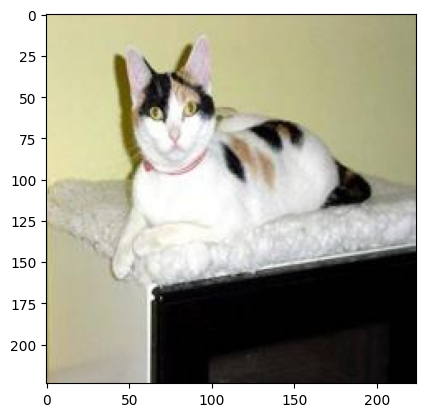

In [28]:
#resized cat image
img = mpimg.imread('/content/image resized/cat.4808.jpg')
imgplt = plt.imshow(img)
plt.show()

Creating labels for resized images of dogs and cats , cat - 0, dog - 1

In [29]:
#Creating a for loop
filenames = os.listdir('/content/image resized')


labels = []

for file_name in filenames:
    if file_name.startswith('dog'):
        labels.append(1)
    else:
        labels.append(0)


In [30]:
print(filenames[0:5])

['cat.4808.jpg', 'dog.11702.jpg', 'dog.1662.jpg', 'cat.4595.jpg', 'dog.10223.jpg']


In [31]:
print(len(filenames))

1000


In [32]:
print(labels[0:5])
print(len(labels))

[0, 1, 1, 0, 1]
1000


In [33]:
#counting the images of dogs and cats out of 4000 imgs
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[500 500]


Converting all the resized images to numpy arrays

In [34]:
import cv2
import glob

In [35]:
image_directory = '/content/image resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [36]:
print(dog_cat_images)

[[[[162 210 214]
   [162 210 214]
   [163 211 215]
   ...
   [117 155 155]
   [115 153 153]
   [114 152 152]]

  [[164 212 216]
   [165 213 217]
   [165 213 217]
   ...
   [119 157 157]
   [118 156 156]
   [116 154 154]]

  [[166 214 218]
   [167 215 219]
   [167 215 219]
   ...
   [122 160 160]
   [120 158 158]
   [119 157 157]]

  ...

  [[116 151 164]
   [124 158 171]
   [133 165 178]
   ...
   [  1   1   1]
   [  1   1   1]
   [  1   1   1]]

  [[124 158 171]
   [128 162 175]
   [135 167 180]
   ...
   [  1   1   1]
   [  1   1   1]
   [  1   1   1]]

  [[130 164 177]
   [133 167 180]
   [141 170 184]
   ...
   [  1   1   1]
   [  1   1   1]
   [  1   1   1]]]


 [[[ 43  73  68]
   [ 43  75  70]
   [ 46  78  73]
   ...
   [ 26  58  39]
   [ 33  65  46]
   [ 35  70  50]]

  [[ 44  74  69]
   [ 45  75  70]
   [ 46  78  73]
   ...
   [ 27  59  40]
   [ 34  66  47]
   [ 37  72  52]]

  [[ 46  74  68]
   [ 45  76  69]
   [ 46  79  72]
   ...
   [ 30  62  43]
   [ 36  68  49]
   [ 39  74

In [37]:
type(dog_cat_images)

numpy.ndarray

In [38]:
print(dog_cat_images.shape)

(1000, 224, 224, 3)


In [39]:
x = dog_cat_images
y = np.asarray(labels)

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
print(x.shape, x_train.shape, x_test.shape)

(1000, 224, 224, 3) (800, 224, 224, 3) (200, 224, 224, 3)


In [41]:
#scaling the data
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [42]:
x_train_scaled

array([[[[0.44313725, 0.38039216, 0.35686275],
         [0.36862745, 0.30588235, 0.28235294],
         [0.35294118, 0.29019608, 0.26666667],
         ...,
         [0.1372549 , 0.13333333, 0.21176471],
         [0.16470588, 0.16862745, 0.25098039],
         [0.11372549, 0.11764706, 0.2       ]],

        [[0.41568627, 0.35294118, 0.32941176],
         [0.36470588, 0.30196078, 0.27843137],
         [0.35686275, 0.29411765, 0.27058824],
         ...,
         [0.21568627, 0.21568627, 0.30980392],
         [0.21568627, 0.21960784, 0.32156863],
         [0.10588235, 0.10980392, 0.21176471]],

        [[0.38823529, 0.3254902 , 0.30196078],
         [0.36862745, 0.30588235, 0.28235294],
         [0.35294118, 0.29803922, 0.2745098 ],
         ...,
         [0.39607843, 0.4       , 0.53333333],
         [0.3254902 , 0.33333333, 0.47058824],
         [0.18431373, 0.19215686, 0.32941176]],

        ...,

        [[0.28235294, 0.40392157, 0.39215686],
         [0.31372549, 0.43529412, 0.42352941]

Building the neural network, by using pretrained model

In [43]:
import tensorflow as tf
import tensorflow_hub as hub

In [44]:
mobilenet_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [45]:
import tensorflow as tf

num_of_classes = 2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(num_of_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()


# import tensorflow as tf

# # Number of output classes (cat and dog)
# num_of_classes = 2

# # Load pretrained MobileNetV2 model
# # include_top=False removes the original ImageNet classifier
# # weights='imagenet' loads weights learned from ImageNet dataset
# base_model = tf.keras.applications.MobileNetV2(
#     input_shape=(224, 224, 3),
#     include_top=False,
#     weights='imagenet'
# )

# # Freeze the pretrained model so its weights are not updated during training
# base_model.trainable = False

# # Define the input layer for the model
# # Images must be of shape (224, 224, 3)
# inputs = tf.keras.Input(shape=(224, 224, 3))

# # Preprocess input images as required by MobileNetV2
# # This scales pixel values to the range expected by the pretrained model
# x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# # Pass the preprocessed images through the pretrained MobileNetV2
# # training=False ensures BatchNormalization layers run in inference mode
# x = base_model(x, training=False)

# # Apply Global Average Pooling to convert feature maps into a single feature vector
# # This reduces parameters and helps prevent overfitting
# x = tf.keras.layers.GlobalAveragePooling2D()(x)

# # Final classification layer
# # Softmax activation outputs probabilities for each class (cat vs dog)
# outputs = tf.keras.layers.Dense(num_of_classes, activation='softmax')(x)

# # Create the final model by connecting inputs and outputs
# model = tf.keras.Model(inputs, outputs)

# # Display the model architecture and parameter count
# model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [46]:
# Image
#   ↓
# Normalization
#   ↓
# MobileNetV2 (frozen)
#   ↓
# Feature vector
#   ↓
# Classifier (trainable)
#   ↓
# Cat or Dog

In [47]:
model.compile(

    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [49]:
model.fit(x_train_scaled, y_train, epochs=5)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - acc: 0.4757 - loss: 0.7189
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - acc: 0.5147 - loss: 0.6950
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - acc: 0.5499 - loss: 0.6922
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - acc: 0.5412 - loss: 0.6823
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - acc: 0.5278 - loss: 0.6904


In [50]:
score, acc = model.evaluate(x_test_scaled, y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - acc: 0.4858 - loss: 0.6920
Test Loss = 0.6920433044433594
Test Accuracy = 0.49000000953674316


Predictive System

Path of the image to be predicted: /content/cat.jpg


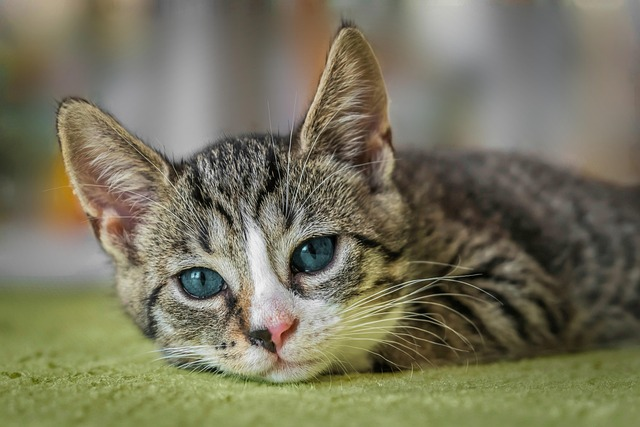

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
The image represents a Cat


In [52]:
input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')